# Artificial Neural Network for Wine Quality Classification
Dataset: UCI Wine Quality

### Import Libaries

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

### Import dataset

In [2]:
# UCI dataset URLs
red_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
white_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

# The files use semicolon separators
red_wine = pd.read_csv(red_url, sep=";")
white_wine = pd.read_csv(white_url, sep=";")

# wine type indicator
red_wine["wine_type"] = "red"
white_wine["wine_type"] = "white"

# Combine datasets
wine = pd.concat([red_wine, white_wine], axis=0).reset_index(drop=True)

wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [3]:
print(wine.shape)

(6497, 13)


In [4]:
print(wine["quality"].value_counts().sort_index())

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


In [9]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  wine_type             6497 non-null   object 
 13  high_quality          6497 non-null   int64  
dtypes: float64(11), int64(2), object(1)
memory usage: 710.7+ KB


### Create target variable

In [10]:
# Convert wine_type to 0 and 1
wine["wine_type"] = wine["wine_type"].map({
    "red": 0,
    "white": 1
})

In [11]:
# Binary classification:
# 1 = high quality wine, 0 = low or average quality wine
wine["high_quality"] = np.where(wine["quality"] >= 7, 1, 0)

X = wine.drop(columns=["quality", "high_quality"])
y = wine["high_quality"]

### Train-test split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### Scale features

In [13]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)


### DataLoaders

In [14]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

### Define neural network

In [15]:
class WineQualityNN(nn.Module):
    def __init__(self, input_dim):
        super(WineQualityNN, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.20),

            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

input_dim = X_train_tensor.shape[1]
model = WineQualityNN(input_dim)

print(model)

WineQualityNN(
  (network): Sequential(
    (0): Linear(in_features=12, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=32, out_features=16, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=16, out_features=1, bias=True)
    (7): Sigmoid()
  )
)


### Loss function and optimizer

In [16]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### Train model

In [17]:
epochs = 100

train_losses = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0

    for batch_X, batch_y in train_loader:
        # Forward pass
        predictions = model(batch_X)
        loss = criterion(predictions, batch_y)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    average_loss = epoch_loss / len(train_loader)
    train_losses.append(average_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch + 1}/{epochs}], Loss: {average_loss:.4f}")

Epoch [10/100], Loss: 0.3751
Epoch [20/100], Loss: 0.3639
Epoch [30/100], Loss: 0.3564
Epoch [40/100], Loss: 0.3481
Epoch [50/100], Loss: 0.3410
Epoch [60/100], Loss: 0.3368
Epoch [70/100], Loss: 0.3338
Epoch [80/100], Loss: 0.3325
Epoch [90/100], Loss: 0.3289
Epoch [100/100], Loss: 0.3251


### Evaluate model

In [18]:
model.eval()

with torch.no_grad():
    y_pred_prob = model(X_test_tensor)
    y_pred = (y_pred_prob >= 0.5).int().numpy()

accuracy = accuracy_score(y_test, y_pred)

print("\nTest Accuracy:")
print(round(accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Test Accuracy:
0.8354

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.96      0.90      1044
           1       0.66      0.34      0.45       256

    accuracy                           0.84      1300
   macro avg       0.76      0.65      0.67      1300
weighted avg       0.82      0.84      0.81      1300


Confusion Matrix:
[[1000   44]
 [ 170   86]]


The neural network achieved an overall accuracy of 84%. However, the classification report shows that the model performs much better for the majority class than for the minority class. Class 0 has a recall of 0.96, meaning the model correctly identifies most low or average quality wines. In contrast, class 1 has a recall of only 0.34, indicating that many high quality wines are misclassified as low or average quality. This is likely due to class imbalance, since high quality wines represent a smaller share of the dataset.

Since class 1 is underrepresented, we can use a weighted loss function.

### Improving the model

In [22]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [23]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.20,
    random_state=SEED,
    stratify=y_train_val
)

In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [25]:
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

In [26]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

In [27]:
class ImprovedWineQualityNN(nn.Module):
    def __init__(self, input_dim):
        super(ImprovedWineQualityNN, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.25),

            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(0.15),

            nn.Linear(16, 1)
        )

    def forward(self, x):
        return self.network(x)


input_dim = X_train_tensor.shape[1]
model = ImprovedWineQualityNN(input_dim)

print("\nModel architecture:")
print(model)



Model architecture:
ImprovedWineQualityNN(
  (network): Sequential(
    (0): Linear(in_features=12, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.25, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): ReLU()
    (10): Dropout(p=0.15, inplace=False)
    (11): Linear(in_features=16, out_features=1, bias=True)
  )
)


In [28]:
# 10. Weighted loss function
num_class_0 = (y_train == 0).sum()
num_class_1 = (y_train == 1).sum()

pos_weight_value = num_class_0 / num_class_1
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32)

print("\nPositive class weight:", round(pos_weight_value, 4))

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=0.0001
)


Positive class weight: 4.0881


In [29]:
#  Train model with validation monitoring
epochs = 200
patience = 20

best_val_loss = np.inf
best_model_state = None
patience_counter = 0

train_losses = []
val_losses = []

for epoch in range(epochs):

    # Training phase
    model.train()
    train_loss = 0.0

    for batch_X, batch_y in train_loader:
        logits = model(batch_X)
        loss = criterion(logits, batch_y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)

    # Validation phase
    model.eval()
    val_loss = 0.0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            logits = model(batch_X)
            loss = criterion(logits, batch_y)
            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_model_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch [{epoch + 1}/{epochs}] "
            f"Train Loss: {avg_train_loss:.4f} "
            f"Val Loss: {avg_val_loss:.4f}"
        )

    if patience_counter >= patience:
        print(f"\nEarly stopping at epoch {epoch + 1}")
        break


# Load best model
model.load_state_dict(best_model_state)

Epoch [10/200] Train Loss: 0.8045 Val Loss: 0.7929
Epoch [20/200] Train Loss: 0.7947 Val Loss: 0.7843
Epoch [30/200] Train Loss: 0.7598 Val Loss: 0.7622
Epoch [40/200] Train Loss: 0.7755 Val Loss: 0.7619
Epoch [50/200] Train Loss: 0.7469 Val Loss: 0.7464
Epoch [60/200] Train Loss: 0.7420 Val Loss: 0.7609
Epoch [70/200] Train Loss: 0.7406 Val Loss: 0.7366
Epoch [80/200] Train Loss: 0.7238 Val Loss: 0.7467
Epoch [90/200] Train Loss: 0.7101 Val Loss: 0.7391
Epoch [100/200] Train Loss: 0.6967 Val Loss: 0.7305
Epoch [110/200] Train Loss: 0.7144 Val Loss: 0.7259
Epoch [120/200] Train Loss: 0.6939 Val Loss: 0.7419
Epoch [130/200] Train Loss: 0.6981 Val Loss: 0.7274

Early stopping at epoch 130


<All keys matched successfully>

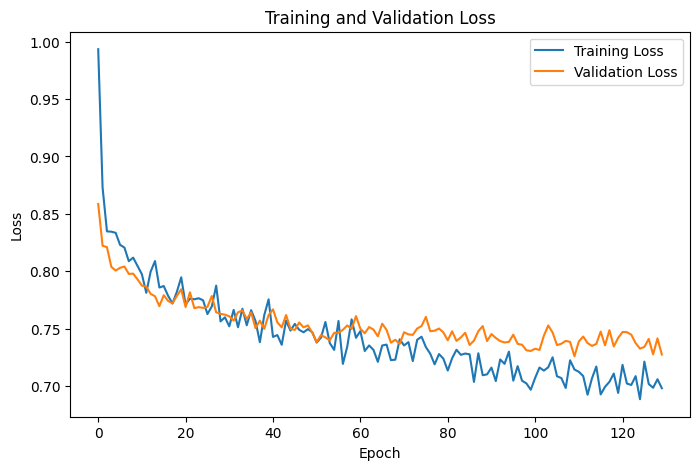

In [32]:
# Plot training and validation loss
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [35]:
# Tune classification threshold using validation set
model.eval()

with torch.no_grad():
    val_logits = model(X_val_tensor)
    val_probs = torch.sigmoid(val_logits).numpy().flatten()

thresholds = np.arange(0.10, 0.91, 0.01)

threshold_results = []

for threshold in thresholds:
    val_preds = (val_probs >= threshold).astype(int)

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_val, val_preds),
        "precision_class_1": precision_score(y_val, val_preds, zero_division=0),
        "recall_class_1": recall_score(y_val, val_preds, zero_division=0),
        "f1_class_1": f1_score(y_val, val_preds, zero_division=0)
    })


In [36]:
threshold_results = pd.DataFrame(threshold_results)

best_threshold_row = threshold_results.sort_values(
    by="f1_class_1",
    ascending=False
).iloc[0]

best_threshold = best_threshold_row["threshold"]

print("\nBest threshold based on validation F1 for class 1:")
print(best_threshold_row)


Best threshold based on validation F1 for class 1:
threshold            0.660000
accuracy             0.801923
precision_class_1    0.496575
recall_class_1       0.710784
f1_class_1           0.584677
Name: 56, dtype: float64


In [37]:
# Final evaluation on test set
with torch.no_grad():
    test_logits = model(X_test_tensor)
    test_probs = torch.sigmoid(test_logits).numpy().flatten()

test_preds = (test_probs >= best_threshold).astype(int)

print("\nFinal Test Accuracy:")
print(round(accuracy_score(y_test, test_preds), 4))

print("\nFinal Classification Report:")
print(classification_report(y_test, test_preds))

print("\nFinal Confusion Matrix:")
print(confusion_matrix(y_test, test_preds))



Final Test Accuracy:
0.7954

Final Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.82      0.87      1044
           1       0.49      0.68      0.57       256

    accuracy                           0.80      1300
   macro avg       0.70      0.75      0.72      1300
weighted avg       0.83      0.80      0.81      1300


Final Confusion Matrix:
[[860 184]
 [ 82 174]]


The improved neural network achieved a final test accuracy of 79.5%. Although this is slightly lower than the baseline model, the improved specification performs substantially better in identifying high-quality wines. The baseline model had a class 1 recall of 0.34, meaning it missed most high-quality wines. After applying class-weighted loss and threshold tuning, class 1 recall increased to 0.68, and the class 1 F1 score improved from 0.45 to 0.57. This suggests that the improved model provides a more balanced classification performance, especially for the minority class.

### Save final model

In [38]:
torch.save(model.state_dict(), "improved_wine_quality_nn_model.pth")

print("\nModel saved as improved_wine_quality_nn_model.pth")


Model saved as improved_wine_quality_nn_model.pth
